In [153]:
from build import Population, Config
from build.models.main import Transformer, NeatModule
from build.optim.scheduler import CosineAnnealing
# from build.util.datetime import eta, clock

from torch import Tensor
from numpy import ndarray as CPUArray

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import warnings
import numpy as np
from numba.core.errors import NumbaPerformanceWarning

In [154]:
# Suppress NumbaPerformanceWarning
warnings.filterwarnings("ignore", category=NumbaPerformanceWarning)

In [155]:
torch.set_printoptions(threshold=10)

In [156]:
device = 'cuda'
dtype  = torch.float32

In [157]:
genome_num = 150

In [158]:
config = Config()

In [159]:
config.genome.init_type = 'normal'
config.genome.weight_init_mean = 0
config.genome.weight_init_std = 1
config.genome.weight_min_value = -np.pi * 10
config.genome.weight_max_value = np.pi * 10
config.genome.weight_mutate_power = 1
config.genome.weight_mutate_rate = 0.5
config.reproduction.min_species_size = genome_num
config.reproduction.purge = 1
config.reproduction.survival_threshold = 0.30
config.reproduction.elitism = 30
config.stagnation.max_stagnation = 1
config.species.compatibility_threshold = 1000000
config.save()
config.load(2)

Created configuration 'GENERAL CONFIG' in NEAT Configuration default-neat_config.txt
Created configuration 'GENOME CONFIG' in NEAT Configuration default-neat_config.txt
Created configuration 'SPECIES CONFIG' in NEAT Configuration default-neat_config.txt
Created configuration 'STAGNATION CONFIG' in NEAT Configuration default-neat_config.txt
Created configuration 'REPRODUCTION CONFIG' in NEAT Configuration default-neat_config.txt
fitness_criterion         = max
fitness_threshold         = 100
pop_size                  = 10000
reset_on_extinction       = True
Loaded configuration 'GENERAL CONFIG' in NEAT Configuration default-neat_config.txt
weight_init_mean          = 0
weight_init_std           = 1
weight_max_value          = 31.41592653589793
weight_min_value          = -31.41592653589793
weight_mutate_power       = 1
weight_mutate_rate        = 0.5
weight_replace_rate       = 0.05
bias_init_mean            = 0.0
bias_init_std             = 1
bias_max_value            = 31.419999999999

In [160]:
batch_size  = 8
seq_len     = 32
input_dims  = 1
output_dims = 1
embedding   = 16
differential = True
layers      = 6
heads       = 4
bias        = False

In [161]:
records = 10

In [162]:
upper   = 30
divider = upper + seq_len

In [163]:
def create(genomes_num: int, low: int, high: int, records, seq_len: int, size: int, inv=True):
    inp = torch.stack([
        torch.stack([
            torch.arange(i, i+(size if not inv else seq_len)) for i in torch.randint(low, high, (seq_len if not inv else size,))
        ]) for _ in range(records)
    ])
    if inv:
        inp = inp.mT
    out = inp.clone() + 1
    return inp.to(device, dtype).unsqueeze(0).expand(genomes_num, *inp.shape) / divider,\
           out.to(device, dtype).unsqueeze(0).expand(genomes_num, *out.shape) / divider

In [164]:
train_inp, train_out = create(genome_num, 0, upper, records, seq_len, output_dims, True)
eval_inp, eval_out   = create(genome_num, 0, upper, records, seq_len, output_dims, True)

In [165]:
train_inp.shape, train_out.shape

(torch.Size([150, 10, 32, 1]), torch.Size([150, 10, 32, 1]))

In [166]:
train_inp.mT

tensor([[[[0.0968, 0.1129, 0.1290,  ..., 0.5645, 0.5806, 0.5968]],

         [[0.3548, 0.3710, 0.3871,  ..., 0.8226, 0.8387, 0.8548]],

         [[0.2419, 0.2581, 0.2742,  ..., 0.7097, 0.7258, 0.7419]],

         ...,

         [[0.3387, 0.3548, 0.3710,  ..., 0.8065, 0.8226, 0.8387]],

         [[0.0000, 0.0161, 0.0323,  ..., 0.4677, 0.4839, 0.5000]],

         [[0.2742, 0.2903, 0.3065,  ..., 0.7419, 0.7581, 0.7742]]],


        [[[0.0968, 0.1129, 0.1290,  ..., 0.5645, 0.5806, 0.5968]],

         [[0.3548, 0.3710, 0.3871,  ..., 0.8226, 0.8387, 0.8548]],

         [[0.2419, 0.2581, 0.2742,  ..., 0.7097, 0.7258, 0.7419]],

         ...,

         [[0.3387, 0.3548, 0.3710,  ..., 0.8065, 0.8226, 0.8387]],

         [[0.0000, 0.0161, 0.0323,  ..., 0.4677, 0.4839, 0.5000]],

         [[0.2742, 0.2903, 0.3065,  ..., 0.7419, 0.7581, 0.7742]]],


        [[[0.0968, 0.1129, 0.1290,  ..., 0.5645, 0.5806, 0.5968]],

         [[0.3548, 0.3710, 0.3871,  ..., 0.8226, 0.8387, 0.8548]],

         [[0.2

In [167]:
train_out.mT

tensor([[[[0.1129, 0.1290, 0.1452,  ..., 0.5806, 0.5968, 0.6129]],

         [[0.3710, 0.3871, 0.4032,  ..., 0.8387, 0.8548, 0.8710]],

         [[0.2581, 0.2742, 0.2903,  ..., 0.7258, 0.7419, 0.7581]],

         ...,

         [[0.3548, 0.3710, 0.3871,  ..., 0.8226, 0.8387, 0.8548]],

         [[0.0161, 0.0323, 0.0484,  ..., 0.4839, 0.5000, 0.5161]],

         [[0.2903, 0.3065, 0.3226,  ..., 0.7581, 0.7742, 0.7903]]],


        [[[0.1129, 0.1290, 0.1452,  ..., 0.5806, 0.5968, 0.6129]],

         [[0.3710, 0.3871, 0.4032,  ..., 0.8387, 0.8548, 0.8710]],

         [[0.2581, 0.2742, 0.2903,  ..., 0.7258, 0.7419, 0.7581]],

         ...,

         [[0.3548, 0.3710, 0.3871,  ..., 0.8226, 0.8387, 0.8548]],

         [[0.0161, 0.0323, 0.0484,  ..., 0.4839, 0.5000, 0.5161]],

         [[0.2903, 0.3065, 0.3226,  ..., 0.7581, 0.7742, 0.7903]]],


        [[[0.1129, 0.1290, 0.1452,  ..., 0.5806, 0.5968, 0.6129]],

         [[0.3710, 0.3871, 0.4032,  ..., 0.8387, 0.8548, 0.8710]],

         [[0.2

In [168]:
def model_size(model: NeatModule):
    return np.sum([param.numel() for param in model.parameters()])

In [169]:
constant = 2 ** np.floor(np.log2(seq_len * embedding)) // 2
constant

256.0

In [170]:
transformer = Transformer(input_dims, output_dims, embedding, seq_len, layers, heads, 1,
                          differential=differential, dropout=0.01, bias=bias,
                          sec_actv=nn.Tanh(),
                          constant=constant, causal_mask=True, device=device, dtype=dtype)
population = Population(genome_num, transformer, config)
transformer, model_size(transformer)


Initialized genomes in  in 0.8s

Created distances cache in 0.36 s
Collected species representatives in 0.0 s
Filled species in 0.0 s
Updated species mapping in 0.0 s
Completed speciating in 0.36 s
Mean genetic distance 0.609, standard deviation 0.449, with 1 species


(Transformer(
   (primary_activation): SiLU()
   (secondary_activation): Tanh()
   (embedder): BufferEmbedding(
     (embedding): Linear[NeatModule](inputs=1, outputs=16, bias=False)
   )
   (encoder): BufferEncoding(
     (encoding): Linear[NeatModule](inputs=1, outputs=16, bias=False)
     (activation): SiLU()
   )
   (transformer): TransformerBase(
     (layers): ModuleList(
       (0): TransformerBlock(
         (attention): Attention(
           (query_proj): Linear[NeatModule](inputs=16, outputs=32, bias=False)
           (key_proj): Linear[NeatModule](inputs=16, outputs=8, bias=False)
           (value_proj): Linear[NeatModule](inputs=16, outputs=4, bias=False)
           (out_proj): Linear[NeatModule](inputs=16, outputs=16, bias=False)
           (rotary_embedding): RoPE()
           (softmax): Softmax(dim=-1)
           (norm): RMSNorm[NeatModule](shape=(4,), eps=1e-08, elementwise_affine=True)
           (diff_lambda): AttentionLambda[NeatModule](heads=4, head_dim=4, layer_id

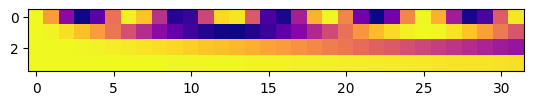

In [171]:
plt.imshow(transformer.transformer.layers[0].attention.rotary_embedding.complex_frequencies[0, 0, ..., 0, :].cpu().float().mT, cmap='plasma')

In [172]:
scheduler = CosineAnnealing(config, 100, 25, 0.001, True, True)

In [173]:
def accuracy(prediction: Tensor, target: Tensor, error=0.01):
    prediction, target = prediction*divider, target*divider
    total: Tensor = ((prediction >= target*(1-error)) & (prediction <= target*(1+error))) == True
    dims = tuple(range(1, train_out.ndim))
    size = np.prod(total.shape[1:])
    acc = (total.float().count_nonzero(dims) / size)
    print(acc.shape)
    acc = acc.max().cpu().item()
    return np.round(acc, 4) * 100

In [174]:
def evaluation(population: Population, **options):
    global train_inp, train_out
    if transformer.genome_num != train_inp.shape[0]:
        train_inp, train_out = create(transformer.genome_num, 0, upper, records, seq_len, output_dims, True)

    losses_plot: list[float] = options['losses']

    out = transformer(train_inp)
    dims = tuple(range(1, train_out.ndim))
    losses = torch.mean((train_out - out) ** 2, dims)
    losses_plot.append(losses.min().cpu().item())
    # scores = (1 - torch.softmax(losses, -1)).cpu().numpy()
    scores = (1 - losses).cpu().numpy()

    for score, gid in zip(scores, transformer.mapping.keys()):
        population.genomes[gid].fitness = score

    scheduler.step()

In [175]:
def train(epochs: int, show=True, checkpoints=5):
    global eval_inp, eval_out
    torch.cuda.empty_cache()
    losses: list[float] = []

    try:
        population.run(evaluation, epochs, losses=losses, verbose=3)
    except (ValueError, KeyboardInterrupt) as e:
        print(e)

    if transformer.genome_num != eval_inp.shape[0]:
        eval_inp, eval_out = create(transformer.genome_num, 0, upper, records, seq_len, output_dims, True)

    # attention.causal_mask = True
    if show:
        plt.plot(np.log10(losses))
        plt.title(f"Loss")

    torch.cuda.empty_cache()
    return losses


 ****** Running generation 1 ****** 

executing fitness function <function evaluation at 0x0000020415E73880> on population, skip-enabled=False
updating population

Population's average fitness: -0.03271 std_dev: 0.90598
Best fitness: 0.96507 - species 1 - id 126
Average adjusted fitness: 0.552

Spawned new genomes in  in 0.51s

Created distances cache in 0.22 s
Collected species representatives in 0.0 s
Filled species in 0.0 s
Updated species mapping in 0.0 s
Completed speciating in 0.23 s
Mean genetic distance 0.736, standard deviation 0.579, with 1 species
Population of 150 members in 1 species:
   ID   age  size  fitness  adj fit  stag
  ====  ===  ====  =======  =======  ====
   2    0   150       --       --     0
Total extinctions: 0
Generation time: 1.068 sec


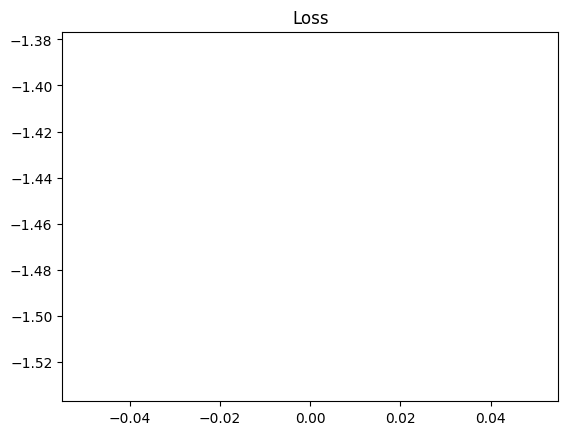

In [176]:
train(1);

In [177]:
best_key = population.best_genome.key if population.best_genome and population.best_genome.key in population.genomes is not None else None
best_key

126

In [178]:
outputs = transformer(eval_inp, verbose=True, get=True)
if best_key is not None:
    idx = transformer.mapping[best_key]
    outputs = outputs[idx:idx+1]
att, att_val = transformer.get_attention()
outputs.shape, att[0].size(), att[0].max(), att[0].min()


Transformer Input =>
tensor([[[[0.1935],
          [0.2097],
          [0.2258],
          ...,
          [0.6613],
          [0.6774],
          [0.6935]],

         [[0.0645],
          [0.0806],
          [0.0968],
          ...,
          [0.5323],
          [0.5484],
          [0.5645]],

         [[0.0323],
          [0.0484],
          [0.0645],
          ...,
          [0.5000],
          [0.5161],
          [0.5323]],

         ...,

         [[0.3226],
          [0.3387],
          [0.3548],
          ...,
          [0.7903],
          [0.8065],
          [0.8226]],

         [[0.2742],
          [0.2903],
          [0.3065],
          ...,
          [0.7419],
          [0.7581],
          [0.7742]],

         [[0.1935],
          [0.2097],
          [0.2258],
          ...,
          [0.6613],
          [0.6774],
          [0.6935]]],


        [[[0.1935],
          [0.2097],
          [0.2258],
          ...,
          [0.6613],
          [0.6774],
          [0.6935]],

  

(torch.Size([1, 10, 32, 1]),
 torch.Size([150, 10, 4, 32, 32]),
 tensor(1., device='cuda:0'),
 tensor(0., device='cuda:0'))

In [179]:
outputs.shape

torch.Size([1, 10, 32, 1])

In [180]:
att[0].shape, att_val[0].shape

(torch.Size([150, 10, 4, 32, 32]), torch.Size([150, 10, 32, 16]))

In [181]:
for i, att_head in enumerate(eval_out[0, :3]):
    att_head = att_head.mT
    # att_head = normalize(att_head)
    print(f"Record {i+1}: {att_head.shape}")
    # print(att_head)
    # plt.imshow(att_head.float().cpu(), cmap='binary')
    print(torch.round(att_head*divider))
    plt.show()

Record 1: torch.Size([1, 32])
tensor([[13., 14., 15.,  ..., 42., 43., 44.]], device='cuda:0')
Record 2: torch.Size([1, 32])
tensor([[ 5.,  6.,  7.,  ..., 34., 35., 36.]], device='cuda:0')
Record 3: torch.Size([1, 32])
tensor([[ 3.,  4.,  5.,  ..., 32., 33., 34.]], device='cuda:0')


In [182]:
for i, att_head in enumerate(outputs[0, :3]):
    att_head = att_head.mT
    # att_head = normalize(att_head)
    print(f"Record {i+1}: {att_head.shape}")
    # print(att_head)
    # plt.imshow(att_head.float().cpu(), cmap='binary')
    print(torch.round(att_head*divider))
    plt.show()

Record 1: torch.Size([1, 32])
tensor([[38., 38., 37.,  ..., 37., 37., 37.]], device='cuda:0')
Record 2: torch.Size([1, 32])
tensor([[38., 37., 36.,  ..., 39., 39., 39.]], device='cuda:0')
Record 3: torch.Size([1, 32])
tensor([[38., 37., 21.,  ..., 40., 40., 40.]], device='cuda:0')


In [183]:
def plot_attention(attention: list[Tensor], genome_index: int, layer_index: int, records: int, randomize=False, size=(1440, 1080), inverse=False, cmap='bone_r'):
    attention: Tensor = attention[layer_index]
    g, b, heads, q, k = attention.shape
    fig, axes = plt.subplots(records, heads, figsize=(size[0]*0.01, size[1]*0.01))
    if isinstance(axes, CPUArray):
        axes = axes.flatten()
    else:
        axes = [axes]
    if inverse:
        axes = axes[::-1]
    x = 0
    if not randomize:
        indices = torch.arange(records)
    else:
        indices = torch.randperm(attention.size(1))[:records]
    for i, record in enumerate(torch.index_select(attention[genome_index], 0, indices.to(device))):
        for j, att_head in enumerate(record):
            if q == 1:
                att_head = att_head.expand(k, k)
            axes[x].imshow(att_head.float().cpu(), cmap=cmap)
            x += 1
    plt.show()
    return att_head

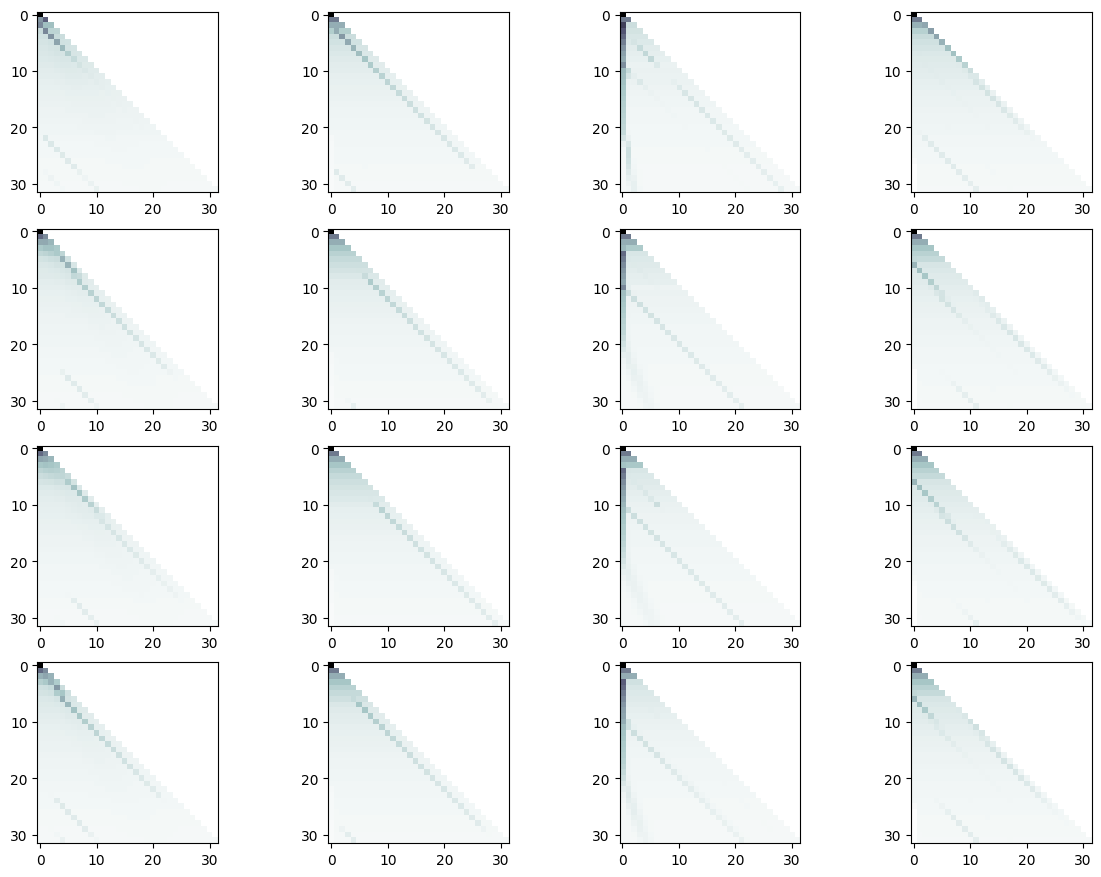

array([[1.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.5       , 0.5       , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.33333334, 0.33333334, 0.33333334, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.00484123, 0.03226195, 0.03252195, ..., 0.03252502, 0.        ,
        0.        ],
       [0.00468479, 0.03123805, 0.03148607, ..., 0.03197898, 0.03148917,
        0.        ],
       [0.00454145, 0.03028373, 0.03052413, ..., 0.03052719, 0.03082439,
        0.03052712]], dtype=float32)

In [184]:
ah = plot_attention(att, 0, 0, 4, True)
ah.cpu().numpy()

In [185]:
accuracy(transformer(eval_inp), eval_out)

torch.Size([150])


3.75

In [186]:
len(transformer.mapping), len(population.genomes)

(150, 150)


 ****** Running generation 2 ****** 

executing fitness function <function evaluation at 0x0000020415E73880> on population, skip-enabled=False
updating population

Population's average fitness: 0.59947 std_dev: 0.48355
Best fitness: 0.96507 - species 2 - id 126
Average adjusted fitness: 0.836

Spawned new genomes in  in 0.53s

Created distances cache in 0.18 s
Collected species representatives in 0.0 s
Filled species in 0.0 s
Updated species mapping in 0.0 s
Completed speciating in 0.18 s
Mean genetic distance 0.715, standard deviation 0.541, with 1 species
Population of 150 members in 1 species:
   ID   age  size  fitness  adj fit  stag
  ====  ===  ====  =======  =======  ====
   3    0   150       --       --     0
Total extinctions: 0
Generation time: 1.039 sec (1.053 average)

 ****** Running generation 3 ****** 

executing fitness function <function evaluation at 0x0000020415E73880> on population, skip-enabled=False
updating population

Population's average fitness: 0.67091 std_

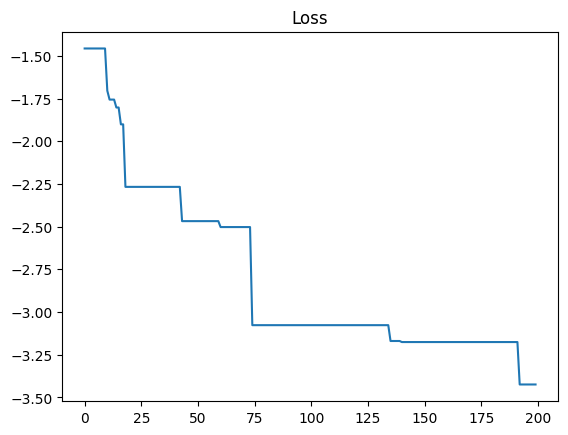

In [187]:
train(100);


 ****** Running generation 202 ****** 

executing fitness function <function evaluation at 0x0000020415E73880> on population, skip-enabled=False
updating population

Population's average fitness: 0.71592 std_dev: 0.32250
Best fitness: 0.99962 - species 43 - id 23238
Average adjusted fitness: 0.874

Spawned new genomes in  in 0.51s

Created distances cache in 0.16 s
Collected species representatives in 0.0 s
Filled species in 0.0 s
Updated species mapping in 0.0 s
Completed speciating in 0.16 s
Mean genetic distance 0.360, standard deviation 0.400, with 1 species
Population of 150 members in 1 species:
   ID   age  size  fitness  adj fit  stag
  ====  ===  ====  =======  =======  ====
  43    1   150      1.0    0.874     0
Total extinctions: 0
Generation time: 1.033 sec (1.010 average)

 ****** Running generation 203 ****** 

executing fitness function <function evaluation at 0x0000020415E73880> on population, skip-enabled=False
updating population

Population's average fitness: 0.708

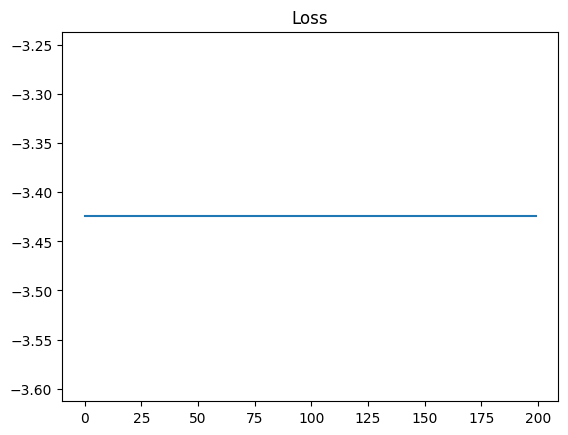

In [188]:
train(100);

In [189]:
len(transformer.mapping), len(population.genomes), transformer.genome_num

(150, 150, 150)

In [190]:
best_key = population.best_genome.key if population.best_genome and population.best_genome.key in population.genomes is not None else None
best_key

23238

In [191]:
accuracy(transformer(eval_inp, keys=best_key), eval_out), \
accuracy(transformer(train_inp, keys=best_key), train_out)

torch.Size([150])
torch.Size([150])


(41.88, 46.25)

In [192]:
outputs = transformer(eval_inp, verbose=True, get=True)
if best_key is not None:
    idx = transformer.mapping[best_key]
    outputs = outputs[idx:idx+1]
att, att_val = transformer.get_attention()


Transformer Input =>
tensor([[[[0.1935],
          [0.2097],
          [0.2258],
          ...,
          [0.6613],
          [0.6774],
          [0.6935]],

         [[0.0645],
          [0.0806],
          [0.0968],
          ...,
          [0.5323],
          [0.5484],
          [0.5645]],

         [[0.0323],
          [0.0484],
          [0.0645],
          ...,
          [0.5000],
          [0.5161],
          [0.5323]],

         ...,

         [[0.3226],
          [0.3387],
          [0.3548],
          ...,
          [0.7903],
          [0.8065],
          [0.8226]],

         [[0.2742],
          [0.2903],
          [0.3065],
          ...,
          [0.7419],
          [0.7581],
          [0.7742]],

         [[0.1935],
          [0.2097],
          [0.2258],
          ...,
          [0.6613],
          [0.6774],
          [0.6935]]],


        [[[0.1935],
          [0.2097],
          [0.2258],
          ...,
          [0.6613],
          [0.6774],
          [0.6935]],

  

In [193]:
for i, att_head in enumerate(eval_out[0, :6]):
    att_head = att_head.mT
    # att_head = normalize(att_head)
    print(f"Record {i+1}: {att_head.shape}")
    # print(att_head)
    # plt.imshow(att_head.float().cpu(), cmap='binary')
    print(torch.round(att_head*divider))
    plt.show()

Record 1: torch.Size([1, 32])
tensor([[13., 14., 15.,  ..., 42., 43., 44.]], device='cuda:0')
Record 2: torch.Size([1, 32])
tensor([[ 5.,  6.,  7.,  ..., 34., 35., 36.]], device='cuda:0')
Record 3: torch.Size([1, 32])
tensor([[ 3.,  4.,  5.,  ..., 32., 33., 34.]], device='cuda:0')
Record 4: torch.Size([1, 32])
tensor([[17., 18., 19.,  ..., 46., 47., 48.]], device='cuda:0')
Record 5: torch.Size([1, 32])
tensor([[14., 15., 16.,  ..., 43., 44., 45.]], device='cuda:0')
Record 6: torch.Size([1, 32])
tensor([[27., 28., 29.,  ..., 56., 57., 58.]], device='cuda:0')


In [194]:
for i, att_head in enumerate(outputs[0, :6]):
    att_head = att_head.mT
    # att_head = normalize(att_head)
    print(f"Record {i+1}: {att_head.shape}")
    # print(att_head)
    # plt.imshow(att_head.float().cpu(), cmap='binary')
    print(torch.round(att_head*divider))
    plt.show()

Record 1: torch.Size([1, 32])
tensor([[14., 15., 15.,  ..., 41., 42., 43.]], device='cuda:0')
Record 2: torch.Size([1, 32])
tensor([[ 8., 10., 10.,  ..., 34., 35., 36.]], device='cuda:0')
Record 3: torch.Size([1, 32])
tensor([[ 8.,  9.,  9.,  ..., 32., 33., 34.]], device='cuda:0')
Record 4: torch.Size([1, 32])
tensor([[17., 18., 19.,  ..., 45., 46., 47.]], device='cuda:0')
Record 5: torch.Size([1, 32])
tensor([[14., 15., 16.,  ..., 42., 43., 44.]], device='cuda:0')
Record 6: torch.Size([1, 32])
tensor([[28., 29., 30.,  ..., 51., 52., 52.]], device='cuda:0')


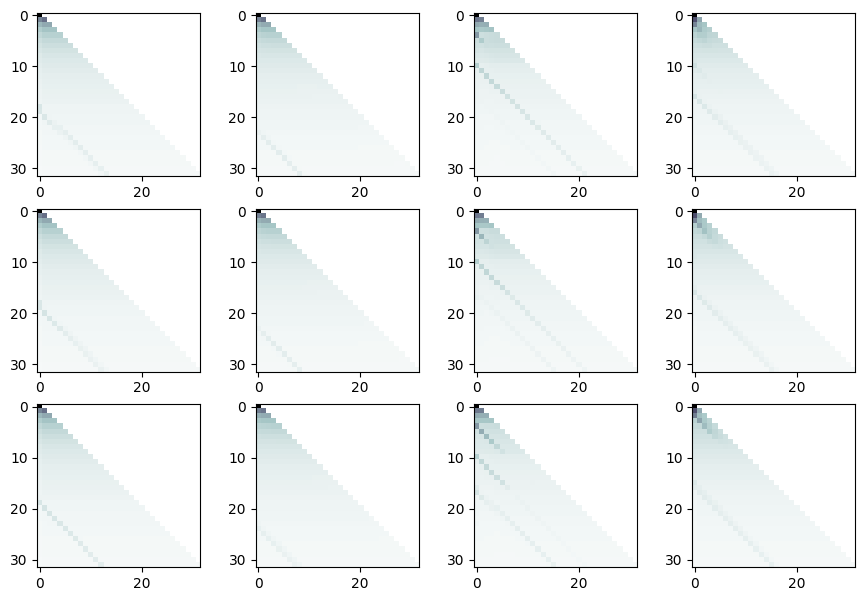

tensor([[1.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.6459, 0.3541, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.4863, 0.2775, 0.2362,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0282, 0.0319, 0.0320,  ..., 0.0320, 0.0000, 0.0000],
        [0.0273, 0.0309, 0.0310,  ..., 0.0310, 0.0310, 0.0000],
        [0.0265, 0.0300, 0.0300,  ..., 0.0300, 0.0300, 0.0300]],
       device='cuda:0')

In [195]:
plot_attention(att, 0, 0, 3, True, size=(1080, 720))

tensor([[ 0,  1,  2,  ...,  7,  8,  9],
        [10, 11, 12,  ..., 17, 18, 19],
        [20, 21, 22,  ..., 27, 28, 29],
        ...,
        [70, 71, 72,  ..., 77, 78, 79],
        [80, 81, 82,  ..., 87, 88, 89],
        [90, 91, 92,  ..., 97, 98, 99]])

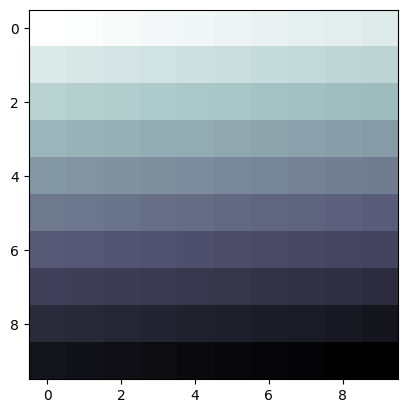

In [196]:
plt.imshow(torch.arange(10*10).view(10, 10), cmap='bone_r')
torch.arange(10*10).view(10, 10)